# NumPy tutorial

NumPy is the fundamental package for scientific computing in Python. It provides a powerful multidimensional array, along with an assortment of fast routines for performing mathematical, logical, sorting, selecting, linear algebra, and statistical operations. See [here](https://docs.scipy.org/doc/numpy/reference/index.html) for the complete list. A growing plethora of scientific and mathematical Python packages use NumPy arrays. If you are going to work on signal/image processing, data analysis, or machine learning projects, it is nearly mandatory to have a solid understanding of NumPy.

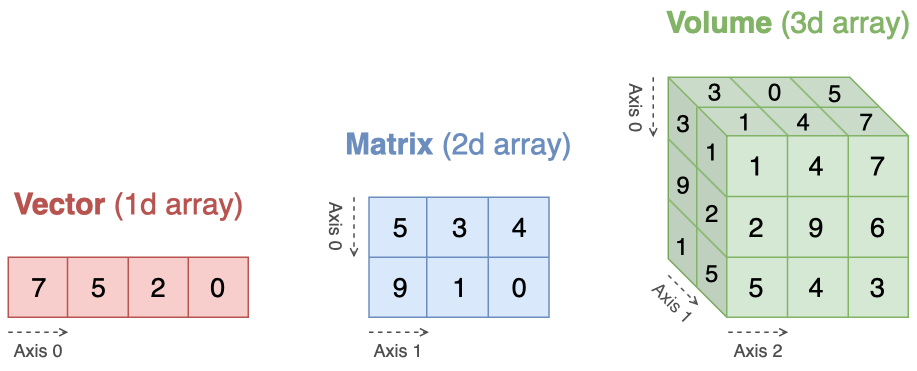


## Why NumPy?

As a simple example, consider the case of multiplying each element in a 1-D sequence with the corresponding element in another sequence of the same length. If the data are stored in two Python lists, we could iterate over each element, as follows.

```python
a = [1,2,3]
b = [4,5,6]
c = []
for i in range(len(a)):
    c.append(a[i] * b[i])
```

This produces the correct answer, but if `a` and `b` each contain millions of numbers, we will pay the price for the inefficiencies of looping in Python. We could accomplish the same task much more quickly in C. This saves all the overhead involved in interpreting the Python code and manipulating Python objects, but at the expense of the benefits gained from coding in Python.

At the core of NumPy package is a powerful array that allows us to perform mathematical operations in a "element-by-element" fashion via pre-compiled C code. This gives us the best of both worlds: the simplicity of Python, with the efficiency of C. The following code does what the earlier example does, at near-C speeds, but with the code simplicity we expect from something based on Python.

```python
import numpy as np

a = np.array([1,2,3])
b = np.array([4,5,6])
c = a * b
```

This example illustrates one of the NumPy’s powerful features: the absence of any explicit looping in the code, also known as **vectorization**. The actual computation takes place “behind the scenes” in optimized pre-compiled C code. Vectorized code has the advantage of being more concise and easier to read.

### Getting started

To start working with NumPy, we need to import the `numpy` package first.

In [ ]:
import numpy as np

After the import, we can refer to NumPy's functions through the prefix `np`. 

---

## 1. NumPy Arrays

A NumPy array stores multiple elements of the same type (usually numbers). It is an object of the class `ndarray` (alias: `array`), which provides the following attributes.


- **``.ndim``**
The number of axes (i.e., dimensions) of the array. 


- **`.shape`**
A tuple of integers indicating the size of the array in each dimension. 


- **`.size`**
The total number of elements of the array. 


There are multiple ways to create and manipulate a NumPy array. Let's review the basic ones.

### Vectors

The simplest way to create an array is by passing a list of numbers to `np.array()`. This produces an array with **one axis**, which is referred to as **vector**.

In [ ]:
list1 = [0,1,2,3,4]

vector = np.array(list1)

print(vector)

 Let's inspect its attributes.

In [ ]:
print("ndim:", vector.ndim)
print("shape:", vector.shape)
print("size:", vector.size)

From the above, we can deduce that a vector of length $N$ presents the following attributes:
 - `.ndim = 1`
 - `.shape = (N,)`
 - `.size = N`

In the mathematical language, the notation $\mathbf{x}\in \mathbb{R}^N$ indicates a vector of size $N$:

$$ 
\mathbf{x} 
= 
\begin{bmatrix}
x_1  \\
x_2 \\
\vdots\\
x_{N}
\end{bmatrix}.
$$

Vectors are conventionally listed out **vertically**. However, this contrasts with the convention adopted by NumPy, where vectors are listed out **horizontally**:

$$
\mathbf{x}^\top = \begin{bmatrix}x_1 &  x_2 & \dots & x_{N} \end{bmatrix}.
$$

Keep that in mind when you implement mathematical expressions in NumPy!

### Matrices

It is also possible to create an array by passing a sequence of lists to `np.array()`. This produces an array with **two axes**, which is referred to as **matrix**. 

In [ ]:
list2 = [[0,1,2], [3,4,5], [6,7,8]]

matrix = np.array(list2)

print(matrix)

Let's inspect its attributes.

In [ ]:
print("ndim:", matrix.ndim)
print("shape:", matrix.shape)
print("size:", matrix.size)

A matrix with $N$ rows and $M$ columns presents the following attributes:
 - `.ndim = 2`
 - `.shape = (N, M)`
 - `.size = N*M`
 
In the mathematical language, the notation $X\in \mathbb{R}^{N\times M}$ indicates a matrix of shape $N\times M$:

$$X = \begin{bmatrix}
x_{1,1} & x_{1,2} & \dots  & x_{1,M}\\
x_{2,1} & x_{2,2} & \dots  & x_{2,M}\\
\vdots  & \vdots  & \ddots & \vdots \\
x_{N,1} & x_{N,2} & \dots  & x_{N,M}
\end{bmatrix}.$$

Either axis of a matrix can have length one, thus yielding 2 special cases.
 
 - A matrix with one row (and multiple columns):
 
 $$X_{\rm row} \in \mathbb{R}^{1\times M}.$$
 
 
 - A matrix with one column (and multiple rows):
 
 $$X_{\rm col} \in \mathbb{R}^{N\times 1}.$$ 
 
 
To avoid errors and unexpected behaviours, it is crucial to understant the difference between vectors (1d arrays) and rows/columns (2d arrays).

In [ ]:
vec = np.array([2,5,9])       # vector (1d array)
row = np.array([[2,5,9]])     # matrix (2d array) with one row
col = np.array([[2],[5],[9]]) # matrix (2d array) with one column

In [ ]:
print("----- vector -----")
print(vec, "-> shape:", vec.shape)

print("\n----- matrix (one row) -----")
print(row, "-> shape:", row.shape)

print("\n----- matrix (one col) -----")
print(col, "-> shape:", col.shape)

**Pay attention to this important detail.**

 - The vector has shape `(3,)`.
 - The single-row matrix has shape `(1,3)`.
 - The single-column matrix has shape `(3,1)`. 
 
Visually, you can remark that matrices have a double pair of brackets, whreas vectors only have one pair.

### ND arrays

There is no limit to the nesting level of lists passed to `np.array()`. The following creates an array with **three axes**, which is referred to as **volume**. 

In [ ]:
list3 = [[[0,1,2], [3,4,5], [6,7,8]],  [[4,1,3], [6,1,3], [9,4,5]]]

volume = np.array(list3)

print(volume)

Let's inspect its attributes. 

In [ ]:
print("ndim:", volume.ndim)
print("shape:", volume.shape)
print("size:", volume.size)

### Reshaping

The shape of an array can be changed with various commands:
 - `.reshape()` reconfigures the array into a new shape,
 - `.ravel()` stretches the array into a vector.
 
The following are examples of reshaping.

In [ ]:
x = np.random.randint(10, size=(3,4))

y = x.reshape(6,2)

z = x.ravel()

In [ ]:
print("----- x -----")
print(x, "-> shape:", x.shape)

print("\n----- x.reshape(6,2) -----")
print(y, "-> shape:", y.shape)

print("\n----- x.ravel() -----")
print(z, "-> shape:", z.shape)

The elements of a reshaped array keep the same order in memory as the original array. The order of these elements is "C-style" by default, that is, the **rightmost index changes the fastest**, so the element after `x[0,0]` is `x[0,1]`, then `x[0,2]`, and so on. 

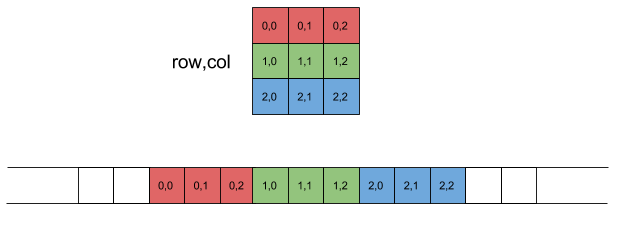

In [ ]:
print("original (flattened):", x.flat[:])
print("reshaped (flattened):", y.flat[:])

Reshaping does not change the number of elements in the original array. If the new shape is not compatible with the original shape, an error is thrown.

In [ ]:
z = x.reshape(2,7)   # This throws an error

Reshaping does not make a copy of the data; rather, it produces a new view of the original array (whenever possible). A view behaves like a regular array, except that its elements are **shared** with the array from which it was created.

In [ ]:
a = np.array([4, 10, 7, 2, 5, 1])

b = a.reshape(2,3) # Shared data!

print("----- a -----")
print(a)
print("\n----- b -----")
print(b)

**Pay attention to this important detail.** The reshaped array shares the same elements of the original array, without making an actual copy of the data (whenever possible). Hence, any modification on the reshaped array is performed on the original array. 

In [ ]:
b[1,0] = -10 # This also modifies the "original" array

print("----- a -----")
print(a)

print("\n----- b -----")
print(b)

To summarize, the functions `reshape()` and `ravel()` reconfigure the elements of an array into a new shape, without changing their values. They work according to the following rules.

 - **Shallow copy:** The reshaped array shares the same elements with the original array.
 
 
 - **Same order:** The shared elements keep the same order in memory.
 

 - **Same size:** The total number of elements does not change. 

### Exercises

Solve the following exercises on array creation and reshaping. Then, proceed to the next section.

#### Quiz 1

> **Create a vector of length `5`, filled with zeros.** 

>  *Hint:* [`np.zeros()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.zeros.html)

In [ ]:
vector_zeros = None # YOUR CODE HERE

#### Quiz 2

> **Create a matrix with `8` rows and `4` columns, filled with one.**

>  *Hint:* [`np.ones()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ones.html)

In [ ]:
matrix_ones = None # YOUR CODE HERE

#### Quiz 3

> **Get the number of rows and columns of a matrix.**

>  *Hint:* [`.shape`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ndarray.shape.html)

In [ ]:
# This is the array to work with
matrix = np.array([[ 1,  2,  3], 
                   [ 4,  5,  6], 
                   [ 7,  8,  9], 
                   [10, 11, 12]])

nrows = None # YOUR CODE HERE
ncols = None # YOUR CODE HERE

#### Quiz 4

> **Propose three different ways to reshape an array into a vector (1d array).**

>  *Hints:* 
 - [`.reshape()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.reshape.html)
 - [`.ravel()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ravel.html)
 - [`.flatten()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.flatten.html)

In [ ]:
# This is the array to work with
volume = np.array([[[5,6,3],
                    [3,2,7],
                    [3,5,1]],
                   
                   [[5,6,3],
                    [3,2,7],
                    [3,5,1]]])

flat_vector = None # YOUR CODE HERE

---

## 2. Vectorized operations

NumPy provides a large panel of **vectorized** operations. Vectorization describes the absence of any explicit looping in the code. Operations are applied on every element of the involved arrays in optimized pre-compiled C code. This is the key difference with respect to python lists, which makes NumPy more suitable to scientific computing. 

### Binary operations

Operations that involve two (or more) arrays are applied **element-by-element**. A new array is created and filled with the result. 

$$
X+Y=\begin{bmatrix}
x_{1,1}+y_{1,1} & x_{1,2}+y_{1,2} & \cdots & x_{1,M}+y_{1,M}\\
x_{2,1}+y_{2,1} & x_{2,2}+y_{2,2} & \cdots & x_{2,M}+y_{2,M}\\
\vdots & \vdots & \ddots & \vdots\\
x_{N,1}+y_{N,1} & x_{N,2}+y_{N,2} & \cdots & x_{N,M}+y_{N,M}
\end{bmatrix}.
$$

In [ ]:
a = np.array( [20, 30, 40, 50] )
b = np.array( [ 0,  1,  2,  3] )

c = a + b

print(c)

The two arrays should be exactly the same size. Errors are thrown if they are not.

In [ ]:
a = np.array([1, 2, 3])
b = np.array([2, 2])

c = a * b  # This will give an error when you run it!

One exception to the above rule is given by operations between an array and a scalar.

In [ ]:
a = np.array([1,2,3])
b = 2

c = a * b

print(c)

Logical operations are also supported in NumPy.

In [ ]:
x = np.array([3, 5, 2, 1, 4, 2])
y = np.array([1, 4, 7, 2, 5, 2])

w = (x > 3) & (y <= x) # "&" --> logical AND
z = (x==2) | (y==1)    # "|" --> logical OR

print("w:", w)
print("z:", z)

### Unary operations

Operations that involve one array are applied **on all the elements**.

In [ ]:
x = np.array([[1,3,1],[2,5,1]])

s = x.sum()

print(s)

Most of the unary operations return a scalar, because they operate on the array as it were a list of numbers, regardless of its shape. By specifying the `axis` parameter, you can apply the "reduction" operation along the specified axis of an array. For example:

 - `axis=0` applies the operation **column-by-column**.
 - `axis=1` applies the operation **row-by-row**.

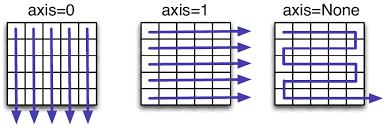

In [ ]:
col_sum = x.sum(axis=0)
row_sum = x.sum(axis=1)

In [ ]:
print("----- x -----")
print(x, "-> shape:", x.shape)

print("\n----- x.sum(axis=0) -----")
print(col_sum, "-> shape:", col_sum.shape)

print("\n----- x.sum(axis=1) -----")
print(row_sum, "-> shape:", row_sum.shape)

Note that reduction operations **change the dimensions of the array**: a matrix becomes a vector. 

You can keep all the axes of the original array by setting the `keepdims` parameter to `True`. 
 - A reduction along `axis=0` gives a single-row matrix.
 - A reduction along `axis=1` gives a single-column matrix.

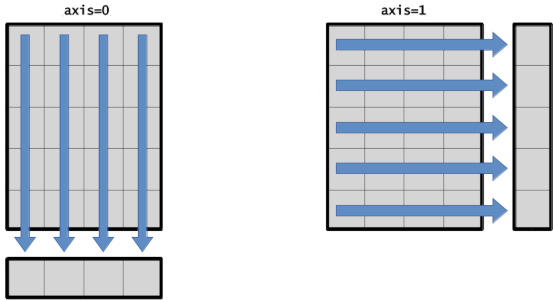

In [ ]:
col_sum_keep = x.sum(axis=0, keepdims=True)
row_sum_keep = x.sum(axis=1, keepdims=True)

In [ ]:
print("----- x -----")
print(x, "-> shape:", x.shape)

print("\n----- x.sum(axis=0, keepdims=True) -----")
print(col_sum_keep, "-> shape:", col_sum_keep.shape)

print("\n----- x.sum(axis=1, keepdims=True) -----")
print(row_sum_keep, "-> shape:", row_sum_keep.shape)

Remark that the shape of the resulting array changes when you specify `keepdims=True`.

### Broadcasting

The term **broadcasting** describes how NumPy combines arrays with different shapes during arithmetics operations. As mentioned above, operations on two arrays are performed in an element-by-element fashion. In the simplest case, the arrays must have exactly the same shape.

In [ ]:
a = np.array([1, 2, 3])
b = np.array([2, 2, 2])

c = a * b

NumPy’s broadcasting rule relaxes this constraint when the shapes of two arrays meet certain constraints. The simplest example occurs when an array and a scalar value are combined in an arithmetic operation. In this case, the scalar is **stretched** during the operation, so as to match the shape of the other array.

In [ ]:
a = np.array([1,2,3])
b = 2

c = a * b

When operating on two arrays, NumPy compares their shapes element-wise. Subject to certain constraints, the smaller array is “broadcast” across the larger array so that they have compatible shapes. The following are three broadcasting scenarios that often arise in practice.

- **Scalars** broadcast to any array.
 
 
 - **Vectors** broadcast to matrices with an equal number of columns.
 
 
 - **Column matrices** broadcast to any vector, and to matrices with an equal number of rows.

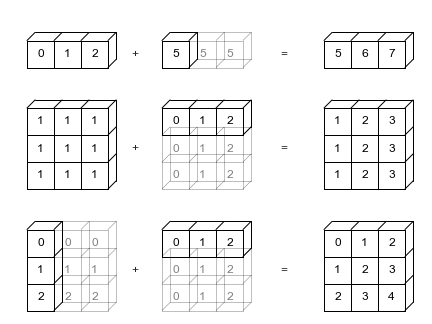

A common beginner mistake in NumPy is to unadvertely perform a binary operation with a single-column matrix and a vector. Due to broadcasting, this produces an unexpected result: each element of the former is combined to every element of the latter, resulting in a matrix of shape equal to the two addends:

$$ \mathbf{x} + \mathbf{y}^\top = \begin{bmatrix}x_1\\\vdots\\x_{N}\end{bmatrix} + \begin{bmatrix}y_1 & \dots & y_{M}\end{bmatrix} = 
\begin{bmatrix}
x_1+y_1 & \dots  & x_1+y_{M}\\
\vdots   &  & \vdots \\
x_{N}+y_1 & \dots  & x_{N}+y_{M}
\end{bmatrix}. $$

In [ ]:
vector = np.array([0,1,2])

column = np.array([[0],[1],[2]])

matrix = column + vector

In [ ]:
print("----- vector -----")
print(vector)

print("\n----- column -----")
print(column)

print("\n----- column + vector -----")
print(matrix)

### Exercises

Solve the following exercises on array operations. Then, proceed to the next section.

#### Quiz 5

> **Given an array `x`, compute the following expression:**
>
> $$ \log\left(\sum_{i=0}^{N-1} \exp(x_i) \right). $$

> *Hint:* 
> - $\exp(\cdot)$ denotes the exponential, which can be computed in numpy with the function `np.exp()`.
> - $\sum_i \cdot$ denotes a summation, which can be computed in numpy with the function `np.sum()`.
> - $\log(\cdot)$ denotes the logarithm, which can be computed in numpy with the function `np.log()`.

In [ ]:
# This is the array to work with
x = np.array([7.1, -5.7, 13])

log_sum_exp = None # YOUR CODE HERE

#### Quiz 6

> **Find the minimum and maximum values of a vector.**
  
> *Hint:*
>    - [`.min()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.amin.html) 
>    - [`.max()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.amax.html)

In [ ]:
# This is the vector to work with
vector = np.array([5, -1, 3, 12, 8, 0])

min_value = None # YOUR CODE HERE
max_value = None # YOUR CODE HERE

#### Quiz 7

> **Compute the mean value of a matrix, of its rows, and of its columns.**

> *Hint:*
>    - [`.mean()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.mean.html)

In [ ]:
np.random.seed(1)

# This is the matrix to work with
matrix = np.random.randint(10,size=(3,4))

mean_all  = None # YOUR CODE HERE
mean_rows = None # YOUR CODE HERE
mean_cols = None # YOUR CODE HERE

---

# 3. Array indexing

NumPy arrays can be indexed and sliced over, much like lists and other Python sequences. 

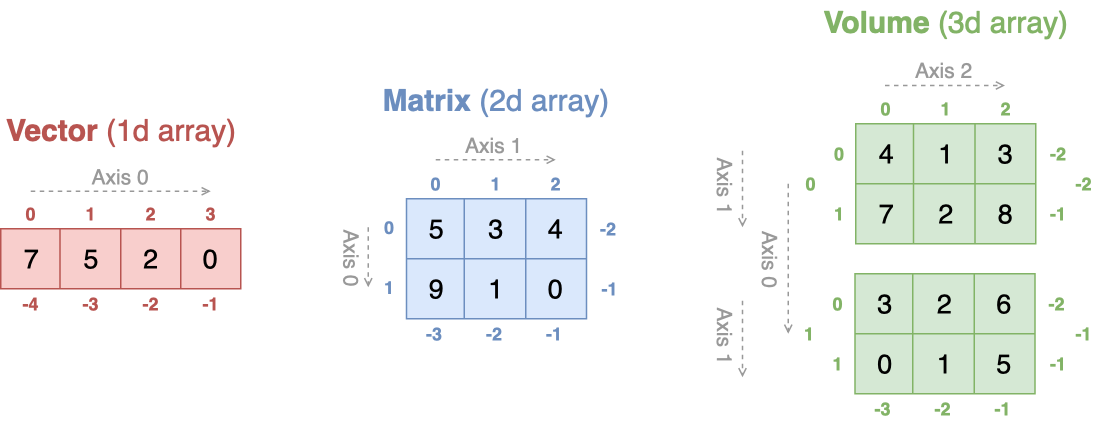

### Single indexing

Indexing for a vector (1d array) is what one would expect. 

 - A single element is extracted by giving its position in brackets.
 
 
 - The index must be between `0` and `size-1`.


- Negative integers between `-size` and `-1` can be used for indexing from the end of the array.

In [ ]:
vector = np.array([2.1, -5.7, 2, 9.4, 8])

vector[0]
vector[2]
vector[-1]

print(vector)
print()
print("vector[ 0]:", vector[0])
print("vector[ 2]:", vector[2])
print("vector[-1]:", vector[-1])

NumPy also supports indexing for multidimensional arrays.

 - A single element is extracted by giving a **tuple of integers, one for each axis**.


 - For each axis, the integer must be between `(0, shape[n]-1)` or `(-shape[n], 1)`.

In [ ]:
matrix = np.array([[1,3,4],[2,5,8],[3,1,4],[7,1,9]])

matrix[1, 2]

print(matrix)
print()
print("matrix[1,2]:", matrix[1,2])

In [ ]:
volume = np.array([[[1,3,1],[2,5,1]], [[5,9,0],[5,7,3]]])

volume[1,0,-2]

print(volume)
print()
print("volume[1,0,-2]:", volume[1,0,-2])

### Slicing

It is possible to extract a contiguous subarray using the slice notation:

 - `vector[start:stop]` - items from `start` to `stop-1`
 - `vector[start:    ]` - items from `start` to the end
 - `vector[     :stop]` - items from the beginning to `stop-1`
 - `vector[     :    ]` - all items (from the beginning to the end)

In [ ]:
vector[1:3]
vector[ :4]
vector[2: ]

print(vector)
print()
print('vector[1:3]\n', vector[1:3])
print()
print('vector[ :4]\n', vector[:4])
print()
print('vector[2: ]\n', vector[2:])

Slicing can be applied to any axis of a multidimensional array, and mixed with other types of indexing.

In [ ]:
matrix[2,:]
matrix[1:3,:2]

print(matrix)
print()
print("matrix[2,:] or matrix[2]\n", matrix[2,:])
print()
print("matrix[1:3,:2]\n", matrix[1:3, :2])

### Copying vs Sharing

Slicing does not make a copy of the selected elements; rather, it produces a new view of the original array (whenever possible). A view behaves like a regular array, except that its elements are **shared** with the array from which it was created.

In [ ]:
a = np.array([4, 10, 7, 2, 5])

b = a[1:3] # Shared data!

print("a:", a)
print("b:", b)

**Pay attention to this important detail.** Any modification to a "sliced array" is actually performed on the array from which it was created.

In [ ]:
b[0] = -1 # this also modifies the "original" array

In [ ]:
print("a:", a)
print("b:", b)

In order to really make a copy of the sliced elements, the method **`copy()`** must be explictly called.

In [ ]:
a = np.array([4, 10, 7, 2, 5])

b = a[1:3].copy() # Copied data!

b[0] = -1 # this does NOT modify the "original" array

print("a:", a)
print("b:", b)

**Remark.** A simple assignment makes neither a copy, nor a view of the original array. It just creates a **new alias** (i.e., a reference) to the assigned array. 

In [ ]:
a = np.array([4, 10, 7, 2, 5])

b = a # Same array!

print("Same array:", a is b)

### Assigning values to sliced arrays

Due to how slicing works, it is possible to assign values to a slice of an array. The only constraint is that the values being assigned to the sliced array must be shape consistent (the same shape, or broadcastable to the shape produced by slicing).

In [ ]:
x = np.arange(10)

print("x:", x)

For example, it is permitted to assign a constant to a slice.

In [ ]:
x[2:7] = -10

print("x:", x)

Alternatively, it is permitted to assign an array of the right size.

In [ ]:
x[2:7] = np.array([10, 20, 30, 40, 50])

print("x:", x)

In both cases, the original array `x` is modified in the positions specified by the slice.

### Advanced indexing

Vectors can be indexed by **one array of integers**. 
 
 - The integer array holds the positions of the elements to be extracted.
 
 - This array can have an arbitrary size.
 
 - The selected values are **deep copied** into an array with **the same shape** as the indexing array.

```
         +---+---+---+---+---+
   idx = | 1 | 1 | 3 | 8 | 5 |
         +---+---+---+---+---+

         +------+------+------+------+------+
x[idx] = | x[1] | x[1] | x[3] | x[8] | x[5] |
         +------+------+------+------+------+
```

Here is a concrete example of integer indexing.

In [ ]:
np.random.seed(1)

# original vector
x = np.random.randint(0, 10, size=12)  

# integer vector of indices
idx = np.array([1,1,3,8,5])

# new vector with the selected values
y = x[idx]  

In [ ]:
print("     x:", x)
print("   idx:", idx)
print("x[idx]:", y)

Matrices can be indexed by **two arrays of integers**. 
 
 - The indexing arrays hold the row/column positions of the elements to be extracted.
  
 
 - The indexing arrays can be any (broadcastable) shape.
 
 
- The selected values are **deep copied** into an array with the **same shape** as the indexing arrays.


```
         +---+---+---+---+---+
     i = | 1 | 1 | 3 | 8 | 5 |
         +---+---+---+---+---+ 
         +---+---+---+---+---+
     j = | 2 | 4 | 5 | 3 | 7 |
         +---+---+---+---+---+

         +--------+--------+--------+--------+--------+
X[i,j] = | X[1,2] | x[1,4] | x[3,5] | x[8,3] | x[5,7] |
         +--------+--------+--------+--------+--------+
```


In general, multiple-axis arrays can be indexed by an array of integers for each axis.

In [ ]:
a = np.arange(12).reshape(3,4)

i = np.array( [[0,1], [1,2]] )  # indices (2d array) for axis 0
j = np.array( [[2,1], [3,3]] )  # indices (2d array) for axis 1

b = a[i,j]   # i and j must have compatible shape

In [ ]:
print("----- a -----")
print(a)
print("\n----- i -----")
print(i)
print("\n----- j -----")
print(j)
print("\n----- a[i,j] -----")
print(b)

Arrays can be also indexed by **one boolean array**. 
 
 - The boolean array indicates both the items to select (`True`) and to discard (`False`). 
 
 - The boolean array must be **the same shape** as the original array.
 
 - The selected elements are **deep copied** into a return **vector (1d array)** of smaller size.
 

```
          +----+----+----+----+----+----+----+----+
      x = | x0 | x1 | x2 | x3 | x4 | x5 | x6 | x7 |
          +----+----+----+----+----+----+----+----+
          
              0       1       2       3       4       5       6       7
          +-------+-------+-------+-------+-------+-------+-------+-------+
   mask = | False | True  | False | True  | False | False | True  | True  |
          +-------+-------+-------+-------+-------+-------+-------+-------+
  
  
          +----+----+----+----+
x[mask] = | x1 | x3 | x6 | x7 |
          +----+----+----+----+
```

The following are concrete examples of boolean indexing.

In [ ]:
np.random.seed(1)

# original vector
x = np.random.randint(0, 10, size=8)  

# boolean vector of indices
mask = np.array([False, True, False, True, False, False, True, True])

# new vector with the selected values
y = x[mask]

In [ ]:
print("      x:", x)
print("   mask:", mask)
print("x[mask]:", y)

In [ ]:
matrix = np.arange(12).reshape(3,4)

mask = matrix > 5  # matrix of booleans (same shape)

vector = matrix[mask] # the result is always a vector

In [ ]:
print("----- matrix -----")
print(matrix)
print("\n----- mask -----")
print(mask)
print("\n----- vector -----")
print(vector)

### Exercises

Solve the following exercises on array indexing and slicing. Then, proceed to the next section.

#### Quiz 8

> **Create a vector of size 10 filled with zero, and set the first and last elements to `1`.**

> *Remark:* The solution can take more than one line of code.

In [ ]:
# YOUR CODE HERE
head_tail = None

#### Quiz 9

> **Swap (in-place) the 2nd and 4th element of a vector.**

> *Remark:* Single indexing extracts one element from an array. In Python, single values are always copied when assigned to a variable.

In [ ]:
# This is the vector to work with
vector = np.array([5, -1, 3, 12, 8, 0])

print("--- before swap ---")
print(vector)

# YOUR CODE HERE
None

print("\n--- after swap ---")
print(vector)

#### Quiz 10

> **Given a matrix, extract the elements indicated in the figure below.**

> *Hint:* Recall that you can extract a contiguous part of a matrix via the slicing notation:
>  
> `matrix[start_row : stop_row : step_row , start_col : stop_col : step_col]`
> 
> 
> You can omit any of the slicing indices. For example, these are valid slicing: `start:stop`, `start:`, `:stop`, `:`, `::step`.

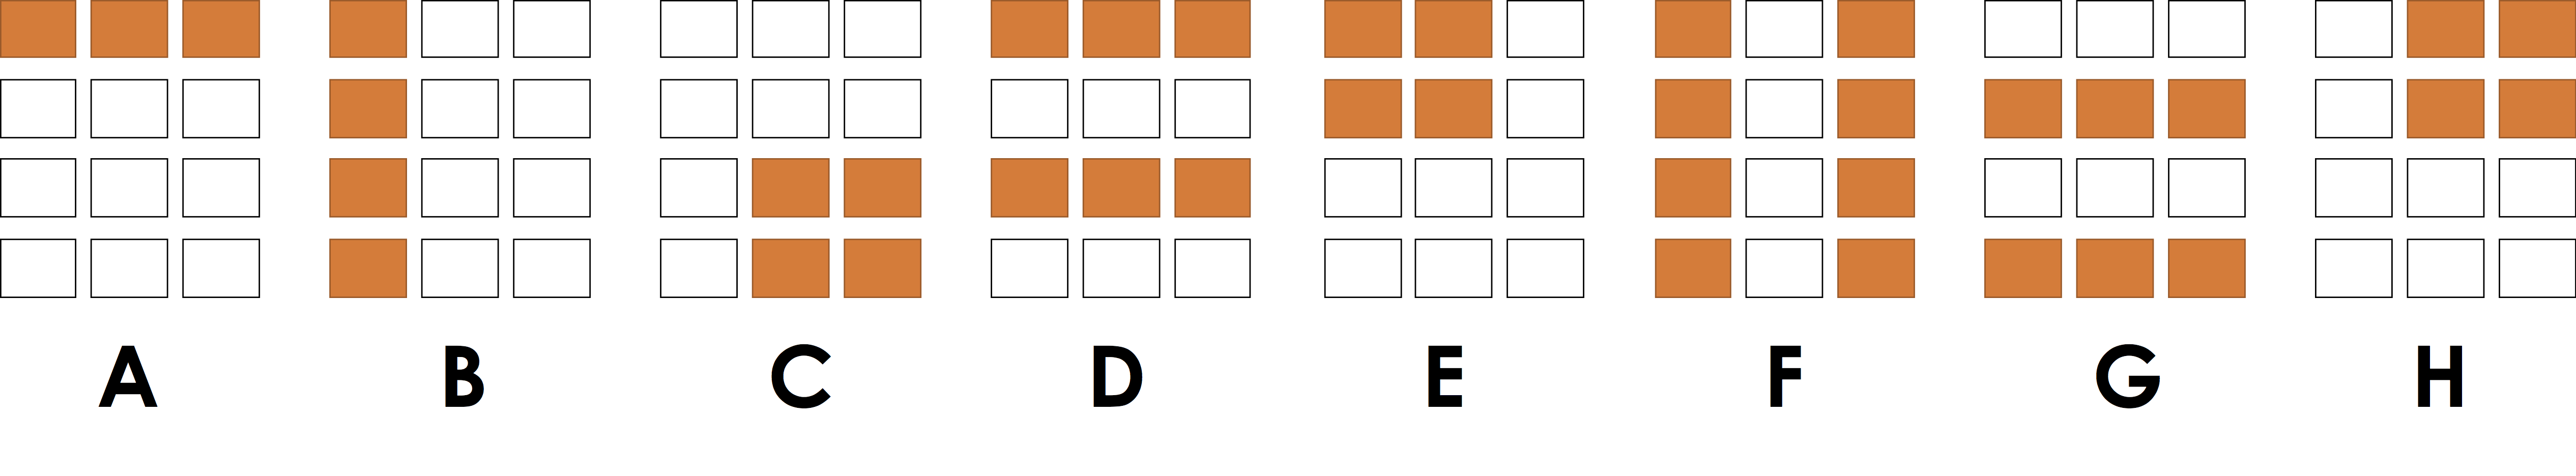

In [ ]:
# This is the matrix to work with
matrix = np.array([[ 1,  2,  3], 
                   [ 4,  5,  6], 
                   [ 7,  8,  9], 
                   [10, 11, 12]])

A = None # YOUR CODE HERE
B = None # YOUR CODE HERE
C = None # YOUR CODE HERE
D = None # YOUR CODE HERE
E = None # YOUR CODE HERE
F = None # YOUR CODE HERE
G = None # YOUR CODE HERE
H = None # YOUR CODE HERE

---

## 4. Linear algebra

NumPy includes many functions for linear algebra in the [`numpy.linalg`](https://docs.scipy.org/doc/numpy/reference/routines.linalg.html) package. 

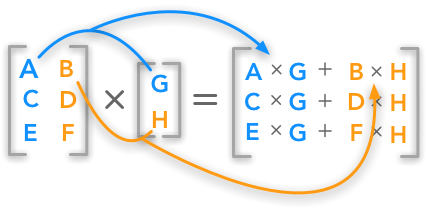

### Multiplication

There are several ways to multiply two vectors. The most natural way is the *element-wise product*.  This works precisely how it sounds: multiply two vectors of the same size element-by-element. 

$$
\mathbf{x} * \mathbf{y} = \begin{bmatrix}
x_1 y_1 \\
\vdots \\
x_{N} y_{N} \\
\end{bmatrix}
$$

In numpy, this operation is performed by the operator `*`.

In [ ]:
x = np.array([2.1, -5.7, 13])
y = np.array([4.3,  9.2, 13])

p = x * y

print(p)

### Scalar product

The scalar product is another way to multiply two vectors of the same dimension. Here is how it works: multiply the vectors element-by-element, then add up the result. For two generic column vectors $\mathbf{x}\in\mathbb{R}^N$ and $\mathbf{y}\in\mathbb{R}^N$, the scalar product is mathematically defined as

$$
\mathbf{x}^\top \mathbf{y} = \begin{bmatrix}x_1 & \dots & x_{N}\end{bmatrix} \begin{bmatrix}y_1\\\vdots\\y_{N}\end{bmatrix} = x_1 y_1 + \dots + x_{N} y_{N} = \sum_{n=1}^{N} x_n y_n.
$$

Numpy provides the operator `@` and the function `np.dot()` to do exactly this. It works on arrays of any dimension.

In [ ]:
dot = x @ y

print("  x:", x)
print("  y:", y)
print("x@y:", dot)

### Matrix-vector product

The operator `@` is also capable of performing matrix-vector or vector-matrix products. Assume that $A\in\mathbb{R}^{N\times K}$, ${\bf b}\in\mathbb{R}^{K}$, and ${\bf c}\in\mathbb{R}^{N}$:

$$
A = 
\begin{bmatrix}
a_{1,1} & \dots & a_{1,K}\\
\vdots &  & \vdots\\
a_{N,1} & \dots & a_{N,K}\\
\end{bmatrix}
\qquad\qquad
{\bf b} = \begin{bmatrix}b_1\\\vdots\\b_{K}\end{bmatrix}
\qquad\qquad
{\bf c} = \begin{bmatrix}c_1\\\vdots\\c_{N}\end{bmatrix}
$$

Mathematically, the exact operation performed by `@` depends on the order of inputs.

- **`A @ b`** multiplies the vector ${\bf b}$ by the *rows* of $A$:

$$
A{\bf b} = \begin{bmatrix} 
\sum_{k=1}^K a_{1,k} b_k \\
\vdots\\
\sum_{k=1}^K a_{N,k} b_k \\
\end{bmatrix}.
$$

- **`c @ A`** multiplies the vector ${\bf c}$ by the *columns* of $A$:

$$
{\bf c}^\top A = \left[ \sum_{n=1}^N a_{n,1} c_n \quad\dots\quad \sum_{n=1}^N a_{n,K} c_n \right].
$$


The result is a vector in both cases.

In [ ]:
A = np.array([[1,3,1],[2,5,1]])
b = np.array([1, 1, 1])
c = np.array([1, 1])

Ab = A @ b
cA = c @ A

print("--- A ---")
print(A)
print("--- b ---")
print(b)
print()
print("A @ b:", Ab)
print("c @ A:", cA)

### Matrix product

When both inputs are matrices, the operator `@` performs a matrix multiplication. Specifically, given two matrices $A\in\mathbb{R}^{M\times N}$ and $B\in\mathbb{R}^{N\times K}$, their product is equal to the scalar product between the rows of $A$ and the columns of $B$:

$$
AB = 
\begin{bmatrix}
\_\!\_\; {\bf a}_1^\top \,\_\!\_ \\
\vdots\\
\_\!\_\; {\bf a}_M^\top \,\_\!\_ \\
\end{bmatrix}
\begin{bmatrix}
| & & |\\[-1em]
{\bf b}_1 & \dots & {\bf b}_K\\
| & & |\\
\end{bmatrix}
=
\begin{bmatrix}
{\bf a}_1^\top{\bf b}_1 & \dots & {\bf a}_1^\top{\bf b}_K\\
\vdots & & \vdots\\
{\bf a}_M^\top{\bf b}_1 & \dots & {\bf a}_M^\top{\bf b}_K
\end{bmatrix}.
$$

In [ ]:
X = np.array([[1,3,1],[2,5,1]])
Y = np.array([[5,1],[9,2],[14,1]])

Z = X @ Y

print("--- X ---")
print(X)
print("--- Y ---")
print(Y)
print("--- X @ Y ---")
print(Z)

---

## 5. More exercises

Congratulations, you finished the tutorial! You will find below additional NumPy exercises of increasing difficulty.

### Quiz 11

> **Create a vector of size 20 with an alternating pattern of `0` and `1`.**

> *Expected output:* `[0, 1, 0, 1, 0, 1, ..., 0, 1]`

In [ ]:
# ADD CODE HERE
zero_one = None

print(zero_one)

### Quiz 12

> **Swap the first half of a vector with its last half.**

> *Example:*  `[1,2,3, 4,5,6]  -->  [4,5,6, 1,2,3]`
     
> *Hints:* 
>  - The size of a vector is given by the attribute `.size` or `.shape[0]`.
>  - Use the integer division `n//2` to compute the length of half a vector.
>  - The function [`np.concatenate()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.concatenate.html) merges a copy of the input vectors into a new array.



In [ ]:
# This is the vector to work with
vector = np.array([4,2,8,  7,1,3])

# ADD CODE HERE
swapped = None

print("vector:", vector)
print("swapped:", swapped)

### Quiz 13

> **Reshape an array of `n` elements into a matrix with `n/2` rows and `2` columns.**

> *Hint:* [`.reshape()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.reshape.html)

In [ ]:
# This is the array to work with
a = np.array([[5,6,3], [3,2,7], [4,2,8], [7,1,3]])

reshaped = None # YOUR CODE HERE

print("--- before ---")
print(a)
print("--- after ---")
print(reshaped)

### Quiz 14

> **Given a vector with an even number of elements, compute the sum of two consecutive elements.** 
> - *Expected result:* Vector holding the sum of 1st and 2nd elements, then the sum of 3rd and 4th elements, and so on.
> - *Example:* [1, 2, 3, 4, 5, 6] --> [3, 7, 11]

> *Hint:* Reshape the vector into a matrix with n/2 rows and 2 columns. 

In [ ]:
np.random.seed(6)

# This is the vector to work with
a = np.random.randint(10,size=(6,))

sum_pairs = None # YOUR CODE HERE

print("vector:", a)
print("sum by pairs:", sum_pairs)

### Quiz 15

> **Given a matrix with an even number of rows, compute the sum of two consecutive rows.** 
> - *Expected result:* Vector holding the sum of elements on 1st and 2nd rows, the sum of elements on 3rd and 4th rows, and so on.

> *Hint:* Reshape the matrix so as to align the rows that must be summed together.

In [ ]:
np.random.seed(1)

# This is the matrix to work with
A = np.random.randint(10,size=(6,4))

sum_rows = None # YOUR CODE HERE

print("---- A ----")
print(A)
print()
print("Sum:", sum_rows)

### Quiz 16

> **Replace the minimum value of a matrix by `-10`.**

> *Hint:* You can reshape the matrix into a vector, get the position of the minimum element with [`.argmin()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.argmin.html), and modify the minimum value.

In [ ]:
np.random.seed(1)

# This is the matrix to work with
matrix = np.random.randint(50, size=(4,6))

print("--- before ---")
print(matrix)

# ADD CODE HERE
None

print()
print("----- after -----")
print(matrix)

### Quiz 17

> **Divide each row of a matrix by its maximum value, and put the result in a new matrix. Exploit broadcasting to avoid loops!**

> *Hint:* Remember what the argument `keepdims` does in the function [`np.max()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.amax.html#numpy.amax).

In [ ]:
np.random.seed(1)

# This is the matrix to work with
matrix = np.random.randint(10, size=(3,6))

# STEP 1. Compute the max along the rows
max_values = None # YOUR CODE HERE

# STEP 2. Divide the matrix by the max values
new_matrix = None # YOUR CODE HERE

### Quiz 18

> **Compute the following expression:**
>
>$$
{\sf sigmoid}({\bf w}^\top {\bf x}) = \frac{1}{1+e^{-(w_0 + w_1 x_1 + \dots + w_Q x_Q)}}
$$
>
>where 
>
>$$
{\bf w} = \begin{bmatrix}w_0\\w_1\\\vdots\\w_Q\end{bmatrix} \in \mathbb{R}^{Q+1}
\qquad\qquad
{\bf x} = \begin{bmatrix}\vphantom{1}\\x_1\\\vdots\\x_Q\end{bmatrix} \in \mathbb{R}^{Q}
$$
>
>with the convention $x_0=1$.

> *Hint:* Note that the vectors don't have the same size:
> - `w` - vector of shape `(Q+1,)`
> - `x` - vector of shape `(Q,)`. 
>
>To get around this, you can proceed as follows:
> - Slice `w` so as to extract the elements `w[1], ..., w[Q]`.
> - Compute the scalar product between `x` and the above elements.
> - Add `w[0]` to the final result.

In [ ]:
# These are the vectors to work with
x = np.array([3, 2, 7])
w = np.array([-3, 2, 0.5, -1])

# STEP 1. Compute 'w0 + w1*x1 + ... + wQ*xQ'.
w_dot_x = None # YOUR CODE HERE
    
# STEP 2. Compute the sigmoid of 'x_dot_w', as defined above.
logistic = None # YOUR CODE HERE

### Quiz 19

> **Create a `8x8` matrix and fill it with a checkerboard pattern.**

> *Expected output:*
>
>`[[0 1 0 1 0 1 0 1]
  [1 0 1 0 1 0 1 0]
  [0 1 0 1 0 1 0 1]
  [1 0 1 0 1 0 1 0]
  [0 1 0 1 0 1 0 1]
  [1 0 1 0 1 0 1 0]
  [0 1 0 1 0 1 0 1]
  [1 0 1 0 1 0 1 0]]`

In [ ]:
# ADD CODE HERE
checkboard = None

print(checkboard)

### Quiz 20

> **Swap (in-place) the 2nd and 4th column of a matrix.**

> *Recall when data is shared or copied:*
>  - **No copy** - A simple assignment produces an **alias** of the original array.
>  - **Shared data** - Slicing creates a **view** of the original array.
>  - **Copied data** - The method `.copy()` makes a **copy** of the original array.

In [ ]:
# This is the matrix to work with
matrix = np.arange(15).reshape(3,5)

print("--- matrix (before swap) ---")
print(matrix)

# ADD CODE HERE
None

print("\n--- matrix (after swap) ---")
print(matrix)

### Quiz 21

> **Find the element in a vector nearest to the value `1`.**

> *Hint:* Given the vector `x`, compute the absolute values of `x-1`, and then find the index `i` of the minimum element.
>  - [`np.abs()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.absolute.html)
>  - [`np.argmin()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.argmin.html)

> *Example: step-by-step* 
>  - Consider the vector `x = [5, -1, 3, 1.2, 8, 0]`. What is the element in `x` nearest to the value `1`?
>  - The operation `x-1` results in the vector `[4, -2, 2, 0.2, 7, -1]`.
>  - The absolute value of `x-1` is thus `[4, 2, 2, 0.2, 7, 1]`.
>  - What is the minimum element of this vector? Take notice of its position. It is the same as the element you are looking for!

In [ ]:
# This is the vector to work with
vector = np.array([5, -1, 3, 1.2, 8, 0])

# ADD CODE HERE
nearest_value = None

print('nearest value:', nearest_value)

### Quiz 22

> **Given a matrix with an even number of columns, compute the sum of two consecutive columns.** 
> - *Expected result:* Vector holding the sum of elements on 1st and 2nd columns, the sum of elements on 3rd and 4th columns, and so on.

> *Hint:* Recall that a matrix is stored in **row-major** order, so you need to come up with a creative way of reshaping the matrix.

In [ ]:
np.random.seed(1)

# This is the matrix to work with
A = np.random.randint(10,size=(6,4))

sum_cols = None # YOUR CODE HERE

print("--- A ---")
print(A)
print()
print("Sum:", sum_cols)

### Quiz 23

> **Implement a function that computes the following expression:**
>
>$$ {\sf softmax}({\bf x}) = 
\begin{bmatrix}
     \dfrac{e^{x_0}}{\sum_{j=0}^{N-1} e^{x_j}}\\
    \vdots  \\
    \dfrac{e^{x_{N-1}}}{\sum_{j=0}^{N-1} e^{x_j}} 
\end{bmatrix}. $$
>
> When the input is a matrix, the function must operate according to an input parameter `axis`:
 - `axis=None` - sum over all the elements 
 - `axis=0` - sum over the columns
 - `axis=1` - sum over the rows.

> *Hint*: In the skeleton function given below, print the shapes of intermediate variables `x_exp`, `x_sum` and `s` to help you with broadcasting. 
> - The shape of `x_sum` must be `(1,1)`, `(1,5)` or `(2,1)` depending on the input parameter `axis`.
>
> - The shape of `x_exp` and `s` must always be `(2,5)`. 
>
> - Then, the division `x_exp/x_sum` will work due to broadcasting.

In [ ]:
def softmax(x, axis=None):
    """Compute the softmax of x"""
        
    # Compute the exponential.
    x_exp = None # YOUR CODE HERE

    # Sum the elements along the specified axis. Don't forget to keep the dimensions!
    x_sum = None # YOUR CODE HERE
    
    # Compute the division. It should automatically use broadcasting!
    s = None # YOUR CODE HERE

    return s

In [ ]:
x = np.array([[9, 2, 5],
              [7, 5, 0]])

s_all  = softmax(x)
s_cols = softmax(x, axis=0)
s_rows = softmax(x, axis=1)

### Quiz 24

> **Implement a function that computes the following expression:**
>
>$$ J({\bf w}) = \sum_{n=1}^N \big(y^{(n)} - {\bf w}^\top {\bf x}^{(n)}\big)^2, $$
>
>where 
>
>$$
{\bf w} = \begin{bmatrix}w_0\\w_1\\\vdots\\w_Q\end{bmatrix} \in \mathbb{R}^{Q+1}
\qquad\qquad
{\bf x}^{(n)} = \begin{bmatrix}\vphantom{1}\\x_1\\\vdots\\x_Q\end{bmatrix} \in \mathbb{R}^{Q}
\qquad\qquad
y^{(n)}\in\mathbb{R}
$$
>
>with the convention $x_0^{(n)}=1$.


> **Hint:** This computation can be vectorized as follows.
>
>- The vectors ${\bf x}^{(n)}$ are stacked in a matrix $X\in\mathbb{R}^{N\times Q}$, whereas the scalars $y^{(n)}$ are stacked in a vector ${\bf y}\in\mathbb{R}^N$:
>
>$$
X = \begin{bmatrix}
\_\!\_\; { {\bf x}^{(1)}}^\top \_\!\_ \\
\vdots\\
\_\!\_\; { {\bf x}^{(N)}}^\top \_\!\_ \\
\end{bmatrix}
\qquad\qquad
{\bf y} = \begin{bmatrix}
{y^{(1)}}^\top \\
\vdots\\
{y^{(N)}}^\top
\end{bmatrix}.
$$
>
>- The products $z^{(n)} = {\bf w}^\top{\bf x}^{(n)}$, for every index $n$, are computed by multiplying $X$ by ${\bf w}$:
>
>$$ {\bf z} = X{\bf w} =
\begin{bmatrix}
{\bf w}^\top{\bf x}^{(1)}\\
\vdots\\
{\bf w}^\top{\bf x}^{(N)}
\end{bmatrix}.$$
>
>
>- The distance $J$ is now equal to the squared norm of the difference between ${\bf z}$ and ${\bf y}$:
>
>$$
J = \|{\bf z} - {\bf y}\|^2 = \sum_{n=1}^{N} \big(z^{(n)}-y^{(n)}\big)^2.
$$
>
> Note hovewer that the shapes of `X` and `w` don't align for a matrix-vector product. To get around this, you can proceed as follows:
> - Slice `w` so as to extract the elements `w[1], ..., w[Q]`.
> - Compute the product between `X` and the above elements.
> - Add `w[0]` to the final result.

In [ ]:
def ssd_cost(w, X, y):
    """Calculates the sum of squared differences.
     
    Arguments:
    w -- flat vector of shape (Q+1,)
    X -- matrix of shape (N, Q)
    y -- flat vector of shape (N,)

    Returns:
    s -- Scalar
    """
    
    # Compute w0 + w1*X1 + ... + wQ*XQ
    w_dot_x = None # YOUR CODE HERE

    # Compute the sum of squared distances between x_dot_w and y
    J = None # YOUR CODE HERE
    
    return J

### Quiz 25

The *Game of Life* is a grid of square cells that can be in one of two possible states: **live** or **dead**. 

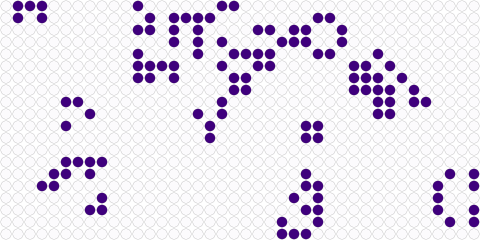

The player creates an initial configuration of live cells and observes how they evolve. Every cell interacts with its 8 neighbours (the cells horizontally, vertically, or diagonally adjacent). At each step in time, the following transitions occur.
 
 - **Underpopulation:** Any live cell with fewer than two live neighbours dies.


 - **Overcrowding:** Any live cell with more than three live neighbours dies.


 - **Stability:** Any live cell with two or three live neighbours lives unchanged to the next generation.
 
 
 - **Rebirth:** Any dead cell with exactly three live neighbours becomes a live cell.
 
 
The initial pattern constitutes the 'seed' of the system. The first generation is created by applying the above rules simultaneously to every cell in the seed. Births and deaths happen simultaneously. The rules continue to be applied repeatedly to create further generations.

The Game of Life can be implemented by a matrix whose elements represent the single cells:
- `0` means the cell is dead,
- `1` means the cell is alive.

```python
board = [[0,0,0,0,0,0],
         [0,0,0,1,0,0],
         [0,1,0,1,0,0],
         [0,0,1,1,0,0],
         [0,0,0,0,0,0],
         [0,0,0,0,0,0]]
```

The cells evolve through a for-loop which involves two operations at each iteration: 
 - counting the neighbors,
 - applying the evolution rules.

In [ ]:
def game_of_life(board, steps):
    for i in range(steps):
        count = neighbor_counting(board)
        board = evolution_rules(board, count)    
    return board

In [ ]:
def neighbor_counting(board):
    padded = np.pad(board, (1,1), 'constant')
    count  = padded[ :-2, :-2] + padded[:-2, 1:-1] + padded[ :-2, 2:] \
           + padded[1:-1, :-2] +                   + padded[1:-1, 2:] \
           + padded[2:  , :-2] + padded[2: , 1:-1] + padded[2:  , 2:]
    return count

> **Implement a function that applies the evolution rules of the Game of Life** (see the description above).

> *Hint:* Use advanced indexing to avoid loops!
> - Translate the evolution rules to boolean conditions,
> - Use the boolean masks to set the new values.

In [ ]:
def evolution_rules(board, count):
    """
    Arguments:
     board -- matrix whose elements indicate whether a cell is dead (0) or alive (1)
     count -- matrix whose elements indicate the number of alive neighbors of a cell

    Returns:
     new_board -- matrix with the same shape as 'board'
    """
    
    new_board = np.zeros_like(board)
            
    # Underpopulation
    R1 = None # YOUR CODE HERE
    ... # YOUR CODE HERE
    
    # overcrowding
    R2 = None # YOUR CODE HERE
    ... # YOUR CODE HERE
    
    # stability 
    R3 = None # YOUR CODE HERE
    ... # YOUR CODE HERE
    
    # rebirth
    R4 = None # YOUR CODE HERE
    ... # YOUR CODE HERE

    return new_board